# Activation plots

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


In [10]:
def relu(x):
    y = x.copy()
    y[y < 0] = 0
    return y

def leaky_relu(x, alpha=0.05):
    y = x.copy()
    y[y < 0] = alpha * y[y < 0]
    return y

def heaviside(x):
    y = x.copy()
    y[y > 0] = 1
    y[y < 0] = 0
    return y

def sigmoid(x):
    y = 1 / (1 + np.exp(-x))
    return y

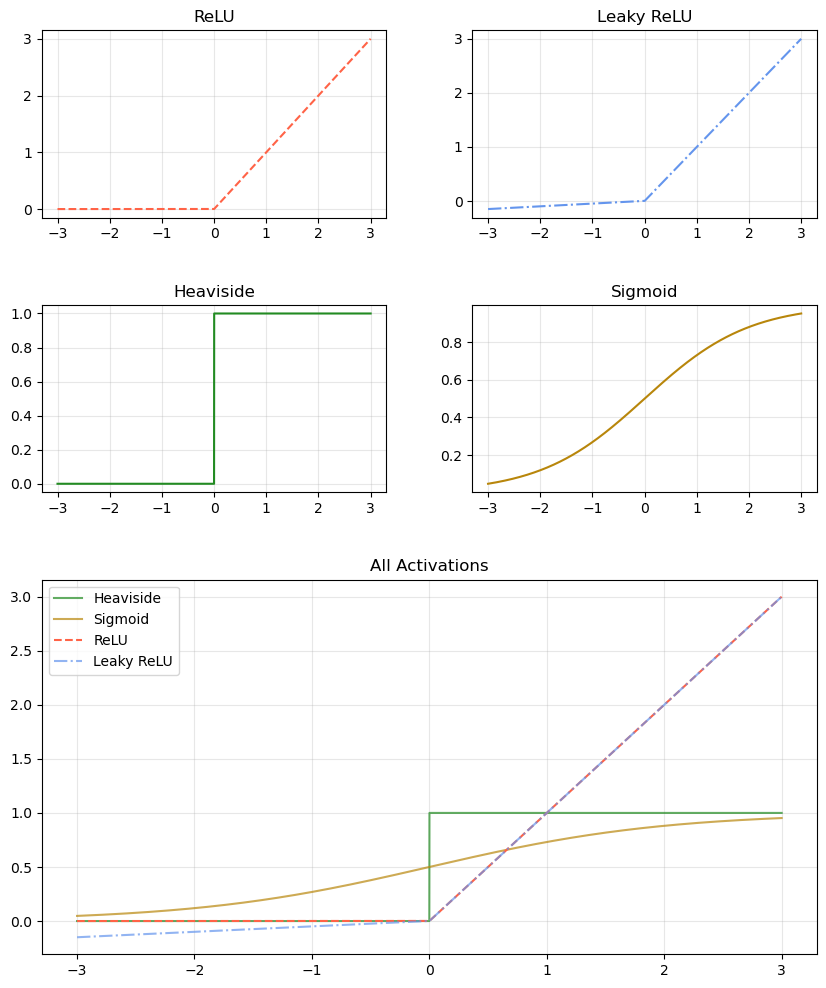

In [17]:
x = np.linspace(-3., 3., 10000)
alpha = 0.7

fig = plt.figure(figsize=(10, 12))

gs = GridSpec(
    3, 2,
    height_ratios=[1, 1, 2],
    hspace=0.35,
    wspace=0.25
)

# Small plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Big plot spanning entire bottom row
ax_big = fig.add_subplot(gs[2, :])

# -------------------------------------------------
# Individual plots
# -------------------------------------------------

ax1.plot(x, relu(x), ls='--', c='tomato')
ax1.set_title("ReLU")

ax2.plot(x, leaky_relu(x), ls='-.', c='cornflowerblue')
ax2.set_title("Leaky ReLU")

ax3.plot(x, heaviside(x), c='forestgreen')
ax3.set_title("Heaviside")

ax4.plot(x, sigmoid(x), c='darkgoldenrod')
ax4.set_title("Sigmoid")

# -------------------------------------------------
# Combined plot
# -------------------------------------------------



ax_big.plot(x, heaviside(x), alpha=alpha, label='Heaviside', c='forestgreen')
ax_big.plot(x, sigmoid(x), alpha=alpha, label='Sigmoid', c='darkgoldenrod')
ax_big.plot(x, relu(x), ls='--', label='ReLU', c='tomato')
ax_big.plot(x, leaky_relu(x), ls='-.', alpha=alpha, label='Leaky ReLU', c='cornflowerblue')

ax_big.set_title("All Activations")
ax_big.legend()

# grids
for ax in [ax1, ax2, ax3, ax4, ax_big]:
    ax.grid(alpha=0.3)